# Plot the results of a dataset

In [47]:
from ferpy.main.measurement import Measurement
import matplotlib.pyplot as plt
import json

In [36]:
with open('../data/entry_example.json', encoding='utf-8') as f:
    publication_dict = json.load(f)

A single file exported from EKHI contains the following keys:

In [37]:
for key in publication_dict.keys():
    print(key)

publication_info
datasets


The content of `publication_info` is explained in the notebook `00_get_bibtex_from_dataset`. The value for `datasets` is a list of dictionaries, each with one dictionary like the following one:

In [38]:
datasets = publication_dict.get('datasets')

In [39]:
datasets[0]

{'dataset_id': '10.1063/1.1729840:dataset-1',
 'material': 'TUNGSTEN',
 'property': ['emittance', 'hemispherical total emittance'],
 'category': ['Metallic elements and alloys', 'Elements'],
 'reported_data': [{'id': 'dad0c037-ee11-4ca1-9c75-853e9dc22d18',
   'description': 'HEMISPHERICAL TOTAL EMITTANCE of TUNGSTEN',
   'changelog': [{'timestamp': '2025-07-06T09:38:06.262785',
     'description': 'Initial generation of the fer data.',
     'user': ''}],
   'correct': True,
   'state': [{'name': 'Temperature Range, K',
     'description': '300-3540',
     'quantity_value': {}},
    {'name': 'Composition (weight percent), Specifications and Remarks',
     'description': 'Tungsten filaments aged 24 hrs at 2400 K; measured in vacuum; smoothed values.',
     'quantity_value': {}}],
   'results': [{'id': '8b76cc24-b643-4a6f-925c-2e88989981e3',
     'name': 'HEMISPHERICAL TOTAL EMITTANCE of TUNGSTEN',
     'description': '',
     'changelog': [{'timestamp': '2025-07-06T09:38:06.262785',
    

Within a dataset, the keys `dataset_id`, `material`, `property` and `category` are metadata-related fields used to properly store and categorize the dataset in EKHI. The key `reported_data` contains a list of Python dictionaries that follow the data structure defined by `fer` ([10.1109/TIM.2025.3588920](10.1109/TIM.2025.3588920)). Thus, those dictionaries can be open using the Python package `ferpy`.

In [40]:
measurement_dict = datasets[0]['reported_data'][0]
measurement_object = Measurement.from_dict(measurement_dict)

Now we can access the results stored inside of that Measurement, and plot them:

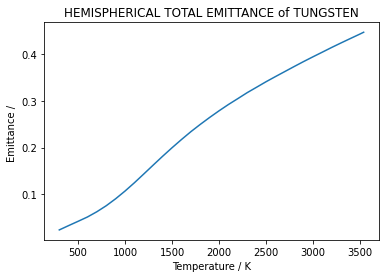

In [54]:
result = measurement_object.results[0]

qv_values = result.values
units = result.units
quantities = result.quantities

plt.plot(
    qv_values[0],
    qv_values[1]
)
plt.xlabel(f"{quantities[0]} / {units[0]}")
plt.ylabel(f"{quantities[1]} / {units[1]}")
plt.title(result.name)
plt.show()